In [1]:
import yfinance as yf # Ver. 0.2.64
import pandas as pd
import numpy as np

# Download stock data using yfinance
tickers = ['AAPL', 'MSFT', 'GOOG', 'AMZN']
start_date = '2023-01-01'
end_date = '2024-10-17'
data_yf = yf.download(tickers, start=start_date, end=end_date)

C:\Users\flash\AppData\Local\Temp\ipykernel_9668\2942792405.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_yf = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  4 of 4 completed


In [2]:
data_yf

Price            Close                                            High  \
Ticker            AAPL        AMZN        GOOG        MSFT        AAPL   
Date                                                                     
2023-01-03  123.330635   85.820000   89.090332  234.423569  129.079551   
2023-01-04  124.602707   85.139999   88.107071  224.169128  126.870724   
2023-01-05  123.281326   83.120003   86.180237  217.525284  125.993082   
2023-01-06  127.817352   86.080002   87.560799  220.088898  128.478033   
2023-01-09  128.339996   87.360001   88.196449  222.231750  131.554669   
...                ...         ...         ...         ...         ...   
2024-10-10  227.978973  186.649994  162.468918  412.741302  228.436849   
2024-10-11  226.495895  188.820007  163.803101  413.217773  228.347280   
2024-10-14  230.228516  187.539993  165.625122  416.016754  230.656516   
2024-10-15  232.766708  187.690002  166.172699  415.619690  236.389846   
2024-10-16  230.706284  186.889999  166.013412  413.019226  231.044705   

Price                                                  Low              \
Ticker            AMZN        GOOG        MSFT        AAPL        AMZN   
Date                                                                     
2023-01-03   86.959999   90.927764  240.460771  122.443150   84.209999   
2023-01-04   86.980003   90.619874  227.857977  123.340509   83.360001   
2023-01-05   85.419998   87.610452  222.652510  123.024948   83.070000   
2023-01-06   86.400002   87.868689  220.901036  123.153137   81.430000   
2023-01-09   89.480003   90.212651  226.263087  128.083618   87.080002   
...                ...         ...         ...         ...         ...   
2024-10-10  188.130005  163.595001  414.240060  226.117641  185.830002   
2024-10-11  189.929993  164.549832  414.021735  226.286862  186.300003   
2024-10-14  189.830002  166.889577  420.880235  227.541026  187.360001   
2024-10-15  188.410004  168.353158  419.331841  231.293553  184.580002   
2024-10-16  187.779999  166.551053  413.257428  228.775268  185.610001   

Price                                     Open                          \
Ticker            GOOG        MSFT        AAPL        AMZN        GOOG   
Date                                                                     
2023-01-03   88.414953  232.290481  128.468178   85.459999   89.219453   
2023-01-04   87.203260  221.096711  125.125335   86.550003   90.391442   
2023-01-05   85.971665  216.987118  125.361983   85.330002   87.471404   
2023-01-06   84.988398  214.629007  124.257564   83.029999   86.766233   
2023-01-09   87.977943  221.537040  128.655553   87.459999   88.588761   
...                ...         ...         ...         ...         ...   
2024-10-10  160.935635  410.071345  226.724816  187.130005  161.403588   
2024-10-11  161.791899  410.170642  228.237789  186.630005  162.618284   
2024-10-14  164.061956  414.408800  227.640554  189.779999  164.191395   
2024-10-15  165.326412  412.165641  232.527815  187.630005  166.411659   
2024-10-16  164.496051  407.421269  230.527125  187.050003  165.306500   

Price                      Volume                                
Ticker            MSFT       AAPL      AMZN      GOOG      MSFT  
Date                                                             
2023-01-03  237.848239  112117500  76706000  20738500  25740000  
2023-01-04  227.280679   89113600  68885100  27046500  50623400  
2023-01-05  222.310037   80962700  67930800  23136100  39585600  
2023-01-06  218.200444   87754700  83303400  26612600  43613600  
2023-01-09  221.576173   70790800  65266100  22996700  27369800  
...                ...        ...       ...       ...       ...  
2024-10-10  412.135863   28183500  27785000  12900500  13848400  
2024-10-11  413.039122   31759200  25751600  10946000  14144900  
2024-10-14  414.656937   39882100  22614400   9981800  16653100  
2024-10-15  419.034059   64751400  32178900  14829300  18900200  
2024-10-16  412.076323   340822

In [3]:
# fill missing data
if np.any(data_yf.isna()):
    data_yf.fillna(method = "ffill", inplace = True)
    print("NAs filled using ffill")
else:
    print("No NAs")

No NAs


In [4]:
# Data Transformation
daily_returns = data_yf['Close'].pct_change() # for every date, how the values changed in comparison to the previous date
rolling_volatility = daily_returns.rolling(window=20).std() # How strong does the daily change vary (always using the last 20 days)
moving_average = data_yf['Close'].rolling(window=50).mean() # what is the mean value (always using the last 50 days)

# Quantitative Analysis

## Monte Carlo Simulation to approximate the probably daily loss over the next day

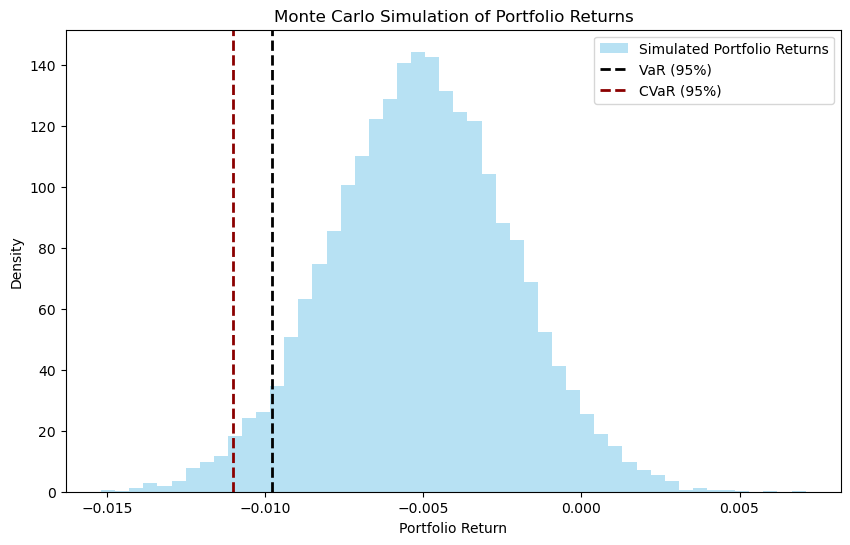

In [5]:
import matplotlib.pyplot as plt
from scipy.stats import norm, uniform, triang

# Monte Carlo simulation for portfolio returns
num_simulations = 10000
# Example weights, assuming 4 assets (adjust as needed)
portfolio_weights = np.array([0.25, 0.25, 0.25, 0.25])

# Get the last available daily returns. This will be used as a basis
# for our random sampling in the Monte Carlo simulation.
last_returns = daily_returns.iloc[-1].values

# Assume a simplified model where returns are normally distributed (can be extended)
mean_returns = last_returns  # Alternatively, calculate historical mean returns
# Scale volatility - this is a simplified example, adjust based on your risk model
std_dev_returns = last_returns.std() * 2


portfolio_returns = []
for _ in range(num_simulations):
    # Generate random returns using NumPy. Here we are simulating a 1-day return for each asset.
    # Normal Distribution(s). The Mean is centered around the last daily returns with an std of 2* the std of the last daily returns.
    # 4 random values are returned from that normal distribution, multiplied with the weights (which asset is supposed to weigh in how much?) and summed.
    # That value is then added to a list.
    # This process happens one thousand times.
    random_returns = norm.rvs(
        loc=mean_returns, scale=std_dev_returns, size=len(tickers))
    portfolio_return = np.sum(portfolio_weights * random_returns)
    portfolio_returns.append(portfolio_return)

# Calculate and visualize Value-at-Risk (VaR)
confidence_level = 0.95
# Of the 10000 values (which should roughly equal a normal distribution) get the 5 percentile
var = np.percentile(portfolio_returns, 100 * (1 - confidence_level))

# Calculate and visualize Conditional Value-at-Risk (CVaR)
# Sort the portfolia values. We want the x values that lie below the confidence level (critical values). Then calculate the mean of these values.
cvar = np.mean(np.sort(portfolio_returns)[:int(
    num_simulations * (1 - confidence_level))])

# Visualization
plt.figure(figsize=(10, 6))
# simple histogram with the 10.000 random values
plt.hist(portfolio_returns, bins=50, density=True, alpha=0.6,
         color='skyblue', label='Simulated Portfolio Returns')
# The Value that marks the 5% percentile
plt.axvline(var, color='black', linestyle='dashed', linewidth=2,
            label=f'VaR ({confidence_level*100:.0f}%)')
# The Mean of the values that are smaller than the 5 % percentile
plt.axvline(cvar, color='darkred', linestyle='dashed', linewidth=2,
            label=f'CVaR ({confidence_level*100:.0f}%)')
plt.xlabel('Portfolio Return')
plt.ylabel('Density')
plt.title('Monte Carlo Simulation of Portfolio Returns')
plt.legend()
plt.show()
plt.close()

We do RISK management. Profit does not pose a risk, only loss. Therefore, we are only interested in the lower 5% - Percentile; in our potential loss

# Qualitative Analysis

In [6]:
import seaborn as sns

# Define risk criteria
risk_criteria = {
    'Categories': ['Market Volatility', 'Regulatory Changes', 'Technology Failure', 'Competition', 'Project Management'],
    'Likelihood': ['Rare', 'Unlikely', 'Possible', 'Likely', 'Almost Certain'],
    'Impact': ['Insignificant', 'Minor', 'Moderate', 'Major', 'Catastrophic']
}

likelihood_scale = {
    'Rare': 1,
    'Unlikely': 2,
    'Possible': 3,
    'Likely': 4,
    'Almost Certain': 5
}

impact_scale = {
    'Insignificant': 1,
    'Minor': 2,
    'Moderate': 3,
    'Major': 4,
    'Catastrophic': 5
}

In [7]:
# Risk scoring function
def calculate_risk_score(likelihood, impact):
    return likelihood_scale[likelihood] * impact_scale[impact]

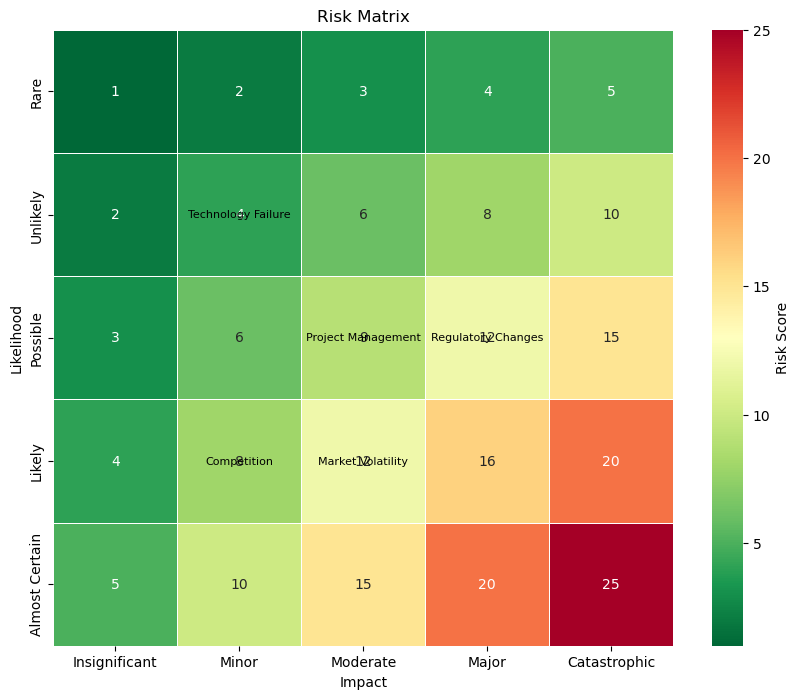

In [8]:
# Example risks
risks = {
    'Market Volatility': {'likelihood': 'Likely', 'impact': 'Moderate'},
    'Regulatory Changes': {'likelihood': 'Possible', 'impact': 'Major'},
    'Technology Failure': {'likelihood': 'Unlikely', 'impact': 'Minor'},
    'Competition': {'likelihood': 'Likely', 'impact': 'Minor'},
    'Project Management': {'likelihood': 'Possible', 'impact': 'Moderate'}

}

# Calculate risk scores
risk_scores = {}
for risk, data in risks.items():
    risk_scores[risk] = calculate_risk_score(
        data['likelihood'], data['impact'])

# Create risk matrix
risk_matrix = pd.DataFrame(
    index=risk_criteria['Likelihood'], columns=risk_criteria['Impact'])
for i in risk_matrix.index:
    for j in risk_matrix.columns:
        risk_matrix.loc[i, j] = likelihood_scale[i] * impact_scale[j]


# Visualize risk matrix
plt.figure(figsize=(10, 8))
sns.heatmap(risk_matrix.astype(int), annot=True, cmap='RdYlGn_r', fmt='d', linewidths=.5,
            cbar_kws={'label': 'Risk Score'})
plt.title('Risk Matrix')
plt.xlabel('Impact')
plt.ylabel('Likelihood')


# Plot risks on the matrix
for risk, score in risk_scores.items():
    likelihood = risks[risk]['likelihood']
    impact = risks[risk]['impact']
    plt.text(impact_scale[impact] - 0.5, likelihood_scale[likelihood] - 0.5, risk,
             fontsize=8, ha='center', va='center', color='black')


plt.show()
plt.close()

Risk 'Technology Failure' avoided.
Risk 'Regulatory Changes' transferred.
Risk 'Market Volatility' mitigated.
Risk 'Competition' accepted.


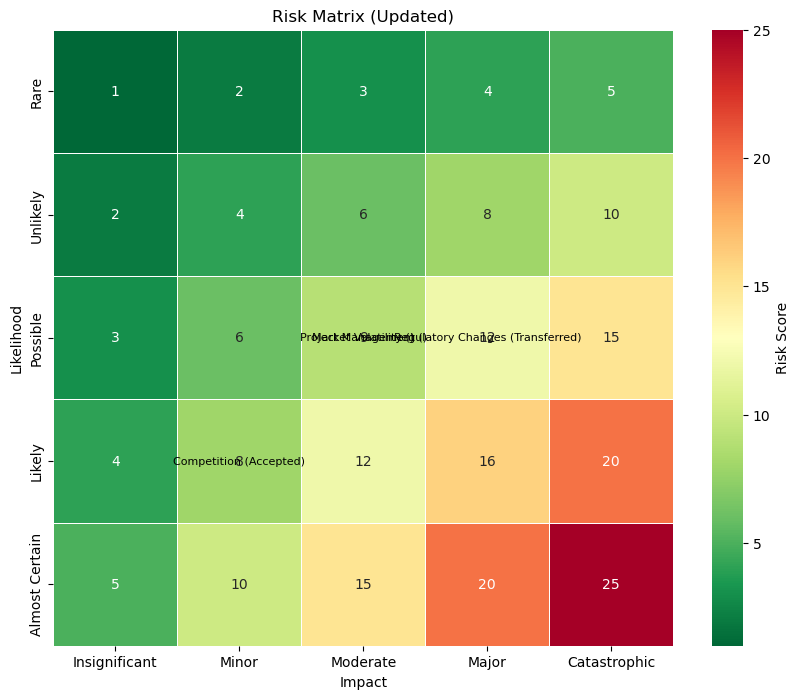

                 Risk               Action    Deadline        Responsible  \
0   Market Volatility  Diversify portfolio  2024-12-31  Portfolio Manager   
1  Regulatory Changes   Legal consultation  2024-11-15         Legal Team   

    Effectiveness  
0  To be assessed  
1  To be assessed  


In [9]:
# Risk Response Functions


def avoid_risk(risk, risks, risk_scores):
    """Removes the risk from the list."""
    if risk in risks:
        del risks[risk]
        del risk_scores[risk]
        print(f"Risk '{risk}' avoided.")
    else:
        print(f"Risk '{risk}' not found.")


def transfer_risk(risk, risks):
    """Marks the risk as transferred."""
    if risk in risks:
        risks[risk]['response'] = 'Transferred'
        print(f"Risk '{risk}' transferred.")
    else:
        print(f"Risk '{risk}' not found.")


def mitigate_risk(risk, risks, risk_scores, new_likelihood=None, new_impact=None):
    """Reduces the likelihood or impact of the risk."""
    if risk in risks:
        if new_likelihood:
            risks[risk]['likelihood'] = new_likelihood
        if new_impact:
            risks[risk]['impact'] = new_impact
        risk_scores[risk] = calculate_risk_score(
            risks[risk]['likelihood'], risks[risk]['impact'])  # Recalculate score
        print(f"Risk '{risk}' mitigated.")
    else:
        print(f"Risk '{risk}' not found.")


def accept_risk(risk, risks):
    """Marks the risk as accepted."""
    if risk in risks:
        risks[risk]['response'] = 'Accepted'
        print(f"Risk '{risk}' accepted.")
    else:
        print(f"Risk '{risk}' not found.")


# Mitigation Tracking
mitigation_plan = pd.DataFrame(
    columns=['Risk', 'Action', 'Deadline', 'Responsible', 'Effectiveness'])


def track_mitigation(risk, action, deadline, responsible, effectiveness, mitigation_plan):
    """Adds a mitigation effort to the tracking DataFrame."""
    new_row = pd.DataFrame({'Risk': [risk], 'Action': [action], 'Deadline': [
                           deadline], 'Responsible': [responsible], 'Effectiveness': [effectiveness]})
    return pd.concat([mitigation_plan, new_row], ignore_index=True)


# Example Risk Responses and Mitigation Tracking
avoid_risk('Technology Failure', risks, risk_scores)
transfer_risk('Regulatory Changes', risks)
mitigate_risk('Market Volatility', risks,
              risk_scores, new_likelihood='Possible')
accept_risk('Competition', risks)


mitigation_plan = track_mitigation('Market Volatility', 'Diversify portfolio',
                                   '2024-12-31', 'Portfolio Manager', 'To be assessed', mitigation_plan)
# Example - Add more mitigation actions as needed
mitigation_plan = track_mitigation('Regulatory Changes', 'Legal consultation',
                                   '2024-11-15', 'Legal Team', 'To be assessed', mitigation_plan)


# Update Risk Matrix Visualization (after responses)
# ... (Code to regenerate the risk matrix plot with updated scores and responses, similar to the code in the Qualitative Risk Assessment section)

# Recalculate risk scores after mitigation (some may have changed)
risk_scores = {}
for risk, data in risks.items():
    risk_scores[risk] = calculate_risk_score(
        data['likelihood'], data['impact'])


# Visualize updated risk matrix
plt.figure(figsize=(10, 8))
sns.heatmap(risk_matrix.astype(int), annot=True, cmap='RdYlGn_r', fmt='d', linewidths=.5,
            cbar_kws={'label': 'Risk Score'})
plt.title('Risk Matrix (Updated)')
plt.xlabel('Impact')
plt.ylabel('Likelihood')

for risk, score in risk_scores.items():
    likelihood = risks[risk]['likelihood']
    impact = risks[risk]['impact']
    # Include response if available
    label = f"{risk} ({risks[risk].get('response', '')})"
    plt.text(impact_scale[impact] - 0.5, likelihood_scale[likelihood] - 0.5, label,
             fontsize=8, ha='center', va='center', color='black')

plt.show()
plt.close()

print(mitigation_plan)

Top 3 Risks:
- Regulatory Changes: 12
- Market Volatility: 9
- Project Management: 9

Mitigation Plan Summary:
                 Risk               Action    Deadline        Responsible   Effectiveness
0   Market Volatility  Diversify portfolio  2024-12-31  Portfolio Manager  To be assessed
1  Regulatory Changes   Legal consultation  2024-11-15         Legal Team  To be assessed



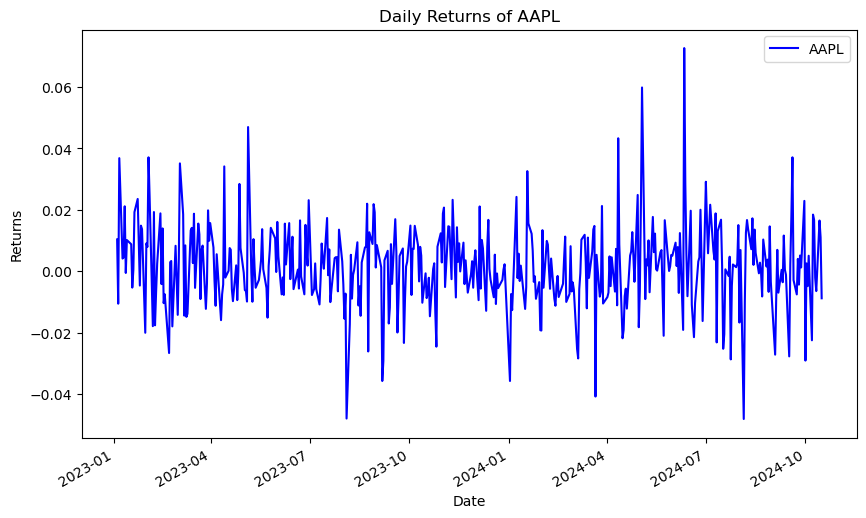

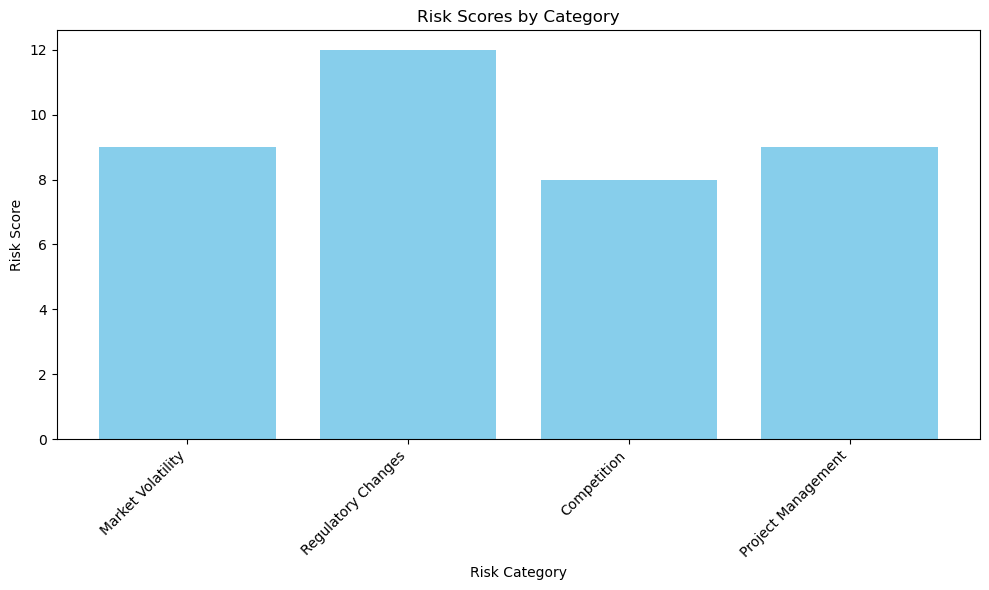

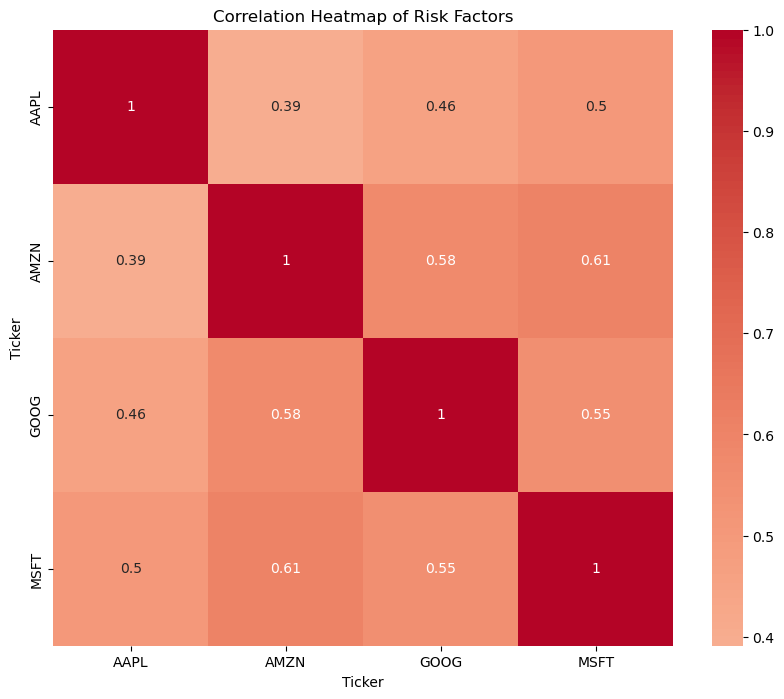

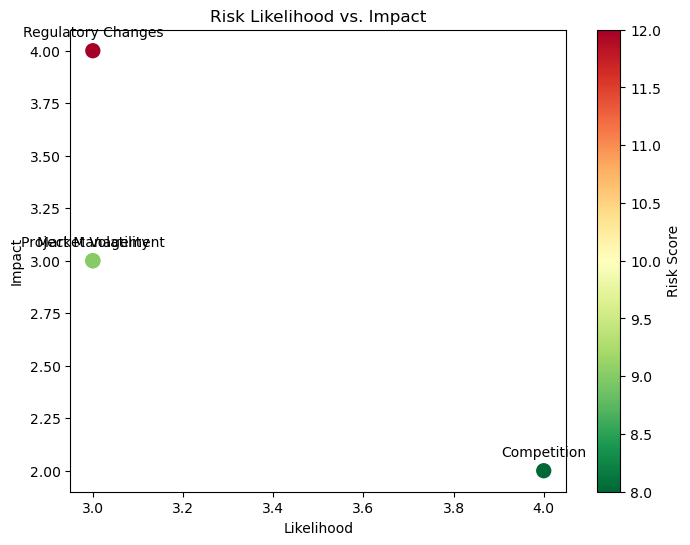

In [10]:
# Generate risk reports


def generate_risk_report(risk_scores, top_n=3):
    """Generates a summary report of key risk metrics."""

    sorted_risks = sorted(risk_scores.items(),
                          key=lambda item: item[1], reverse=True)
    top_risks = sorted_risks[:top_n]

    report = f"Top {top_n} Risks:\n"
    for risk, score in top_risks:
        report += f"- {risk}: {score}\n"

    # Example: Include mitigation plan summary.  Adapt as needed.
    report += "\nMitigation Plan Summary:\n" + mitigation_plan.to_string() + "\n"

    return report


risk_report = generate_risk_report(risk_scores)
print(risk_report)


# Visualizations
plt.figure(figsize=(10, 6))

# Example, if daily_returns from previous sections is available. Adapt this section based on your actual data and desired visualizations.
daily_returns['AAPL'].plot(
    title='Daily Returns of AAPL', color="blue", label="AAPL")
plt.ylabel("Returns")
plt.xlabel("Date")
plt.legend()
plt.show()
plt.close()


risk_categories = list(risks.keys())
risk_category_scores = [risk_scores[risk] for risk in risk_categories]


plt.figure(figsize=(10, 6))
plt.bar(risk_categories, risk_category_scores, color='skyblue')
plt.title('Risk Scores by Category')
plt.xlabel('Risk Category')
plt.ylabel('Risk Score')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels if needed
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()
plt.close()


# Example correlation heatmap (replace with actual risk factors if available)
# Sample correlation matrix (replace with actual data)
correlation_matrix = daily_returns.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm",
            center=0)  # Adjust cmap as needed
plt.title('Correlation Heatmap of Risk Factors')
plt.show()
plt.close()


likelihood_values = [likelihood_scale[risks[risk]
                                      ['likelihood']] for risk in risk_scores]
impact_values = [impact_scale[risks[risk]['impact']]
                 for risk in risk_scores]


plt.figure(figsize=(8, 6))
plt.scatter(likelihood_values, impact_values, s=100, c=list(
    risk_scores.values()), cmap='RdYlGn_r')  # Color by risk score
plt.colorbar(label='Risk Score')
plt.xlabel('Likelihood')
plt.ylabel('Impact')
plt.title('Risk Likelihood vs. Impact')
# Add labels to the points
for i, risk in enumerate(risk_scores):
    plt.annotate(risk, (likelihood_values[i], impact_values[i]),
                 textcoords="offset points", xytext=(0, 10), ha='center')
plt.show()
plt.close()

In [11]:
import logging
import datetime

# Define risk thresholds (example). Adapt these based on your specific needs and risk appetite.
risk_thresholds = {
    # Example: Daily return thresholds for AAPL
    'AAPL_return': {'lower': -0.05, 'upper': 0.05},
    'Market_Volatility_score': {'upper': 10}  # Example: Risk Score threshold
}

In [15]:
def monitor_risks(data, risk_scores, thresholds):
    """Monitors risk indicators and triggers alerts when thresholds are breached."""
    alerts = []

    # Example 1: Check daily returns
    for ticker in ['AAPL']:  # Replace with the tickers you want to monitor
        try:
            latest_return = data['Close'][ticker].pct_change().iloc[-1]
            if latest_return < thresholds[f'{ticker}_return']['lower']:
                alerts.append(
                    f"{ticker} daily return ({latest_return:.4f}) is below the lower threshold ({thresholds[f'{ticker}_return']['lower']:.4f})"
                )
            elif latest_return > thresholds[f'{ticker}_return']['upper']:
                alerts.append(
                    f"{ticker} daily return ({latest_return:.4f}) is above the upper threshold ({thresholds[f'{ticker}_return']['upper']:.4f})"
                )
        except KeyError:
            print(f"Ticker '{ticker}' not found in data.")

    # Example 2: Check qualitative risk scores
    for risk, score in risk_scores.items():
        if risk in thresholds and 'upper' in thresholds[risk] and score > thresholds[risk]['upper']:
            alerts.append(
                f"{risk} score ({score}) exceeds the threshold ({thresholds[risk]['upper']})")

    # Log alerts (example - replace with your desired alerting method, e.g., email or SMS)
    if alerts:
        timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        for alert in alerts:
            log_message = f"{timestamp}: {alert}"
            logging.warning(log_message)  # Using Python's logging module
            print(log_message)  # Print to console for this example
    else:
        print("No risk thresholds breached.")

In [16]:
logging.basicConfig(filename='risk_alerts.log',
                    level=logging.WARNING,  # Log warnings and above
                    format='%(asctime)s - %(levelname)s - %(message)s')


# Example usage with simulated data (replace with your actual data and thresholds)
monitor_risks(data_yf, risk_scores, risk_thresholds)

No risk thresholds breached.


Backtested Portfolio:
Sharpe Ratio: 1.9086
Sortino Ratio: 2.9156
Max Drawdown: -0.1533

Benchmark Portfolio:
Sharpe Ratio: 1.9086
Sortino Ratio: 2.9156
Max Drawdown: -0.1533


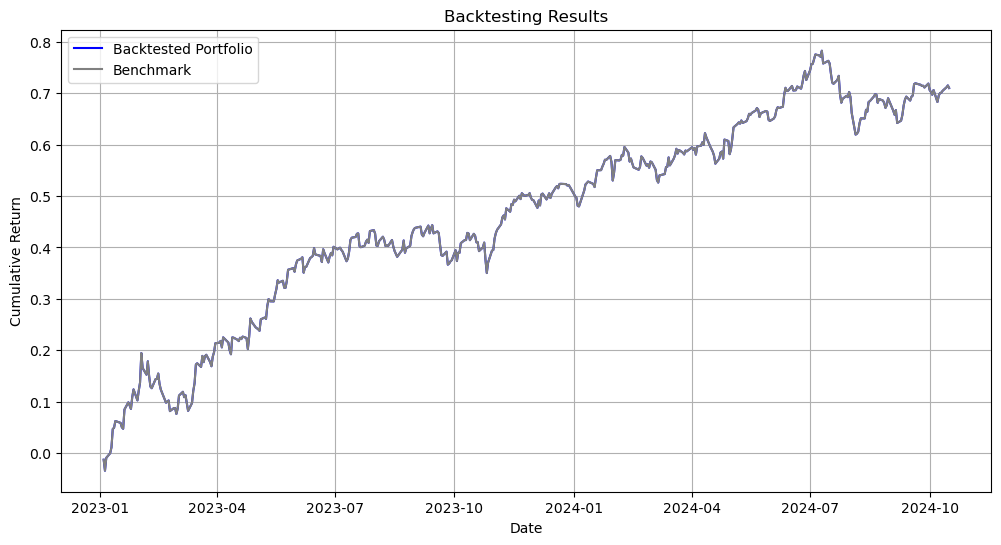

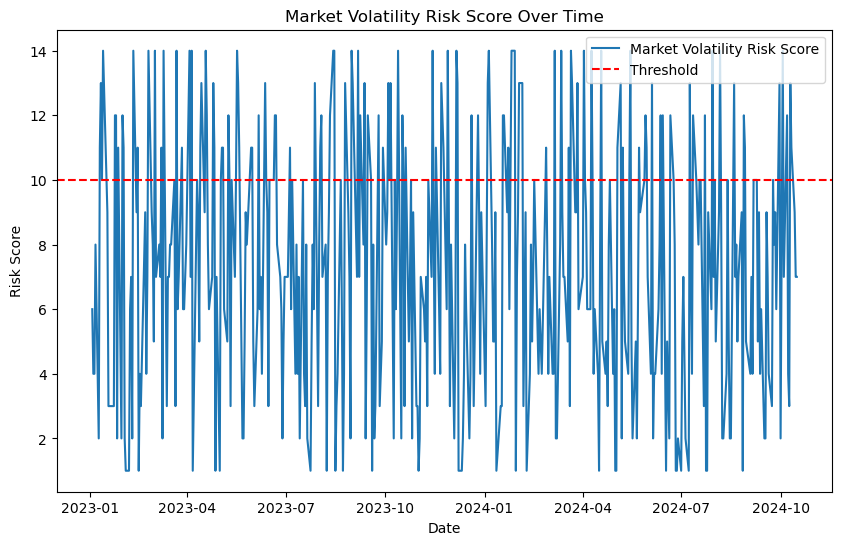

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import empyrical

# Backtesting: Simulate portfolio performance with risk management
# Note: This is a simplified example. Adapt as needed for your specific risk model and data.


def backtest_risk_management(returns, risk_scores, risk_thresholds, weights):
    # Placeholder for portfolio returns during backtesting
    portfolio_returns_backtest = []
    dates = []

    # Simulate trading decisions based on risk scores and thresholds.
    # This example assumes reducing exposure when risk is high
    # Modify this section to reflect your specific risk management strategy
    for i in range(len(returns)):
        risk_breached = False
        for risk, score in risk_scores.items():  # Check risk scores
            # Adapt threshold checks based on your risk model
            if risk in risk_thresholds and 'upper' in risk_thresholds[risk] and score > risk_thresholds[risk]['upper']:
                risk_breached = True
                break

        if risk_breached:
            # Reduce exposure to risky assets (example: move to cash/less volatile asset)
            # Replace with your actual risk reduction strategy
            # Example weights in a reduced-risk portfolio
            adjusted_weights = np.array([0.2, 0.2, 0.2, 0.2])
        else:
            adjusted_weights = weights

        # Calculate portfolio return for the period using adjusted weights.
        portfolio_return = np.sum(adjusted_weights * returns.iloc[i].values)
        portfolio_returns_backtest.append(portfolio_return)

        dates.append(returns.index[i])

    portfolio_returns_backtest = pd.Series(
        portfolio_returns_backtest, index=dates)
    return portfolio_returns_backtest


# Example backtesting. Adapt this to use real historical risk scores and returns.
# Here we simply reuse the daily_returns from previous sections as a proxy for historical data
# and randomly assign risk scores for demonstration. In a real backtest,
# these would be historical risk scores calculated on each day.
risk_scores_history = {}
for i in range(len(daily_returns)):
    # In real-world usage, calculate historical risk scores for each period
    risk_scores_history[daily_returns.index[i]] = {
        risk: np.random.randint(1, 15) for risk in risks}

# Convert the risk_scores_history into a format convenient for backtesting
risk_scores_df = pd.DataFrame(risk_scores_history).T

portfolio_returns_backtest = backtest_risk_management(
    daily_returns, risk_scores_df, risk_thresholds, portfolio_weights
)


# Calculate performance metrics
sharpe_ratio = empyrical.sharpe_ratio(portfolio_returns_backtest)
sortino_ratio = empyrical.sortino_ratio(portfolio_returns_backtest)
max_drawdown = empyrical.max_drawdown(portfolio_returns_backtest)


# Example: Compare against a benchmark (e.g., equal-weighted portfolio). Adapt as needed.
benchmark_returns = daily_returns.mean(axis=1)
sharpe_ratio_benchmark = empyrical.sharpe_ratio(benchmark_returns)
sortino_ratio_benchmark = empyrical.sortino_ratio(benchmark_returns)
max_drawdown_benchmark = empyrical.max_drawdown(benchmark_returns)


# Print the performance metrics

print("Backtested Portfolio:")
print(f"Sharpe Ratio: {sharpe_ratio:.4f}")
print(f"Sortino Ratio: {sortino_ratio:.4f}")
print(f"Max Drawdown: {max_drawdown:.4f}")


print("\nBenchmark Portfolio:")
print(f"Sharpe Ratio: {sharpe_ratio_benchmark:.4f}")
print(f"Sortino Ratio: {sortino_ratio_benchmark:.4f}")
print(f"Max Drawdown: {max_drawdown_benchmark:.4f}")


# Visualization of backtesting results
plt.figure(figsize=(12, 6))
plt.plot(portfolio_returns_backtest.cumsum(),
         label='Backtested Portfolio', color='blue')
plt.plot(benchmark_returns.cumsum(), label='Benchmark', color='gray')
plt.title('Backtesting Results')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()
plt.close()


# Example: You can also visualize individual risk indicator time series data.

plt.figure(figsize=(10, 6))
plt.plot(risk_scores_df["Market Volatility"],
         label="Market Volatility Risk Score")
plt.axhline(risk_thresholds["Market_Volatility_score"]
            ["upper"], color='red', linestyle="--", label="Threshold")
plt.title("Market Volatility Risk Score Over Time")
plt.xlabel("Date")
plt.ylabel("Risk Score")
plt.legend()
plt.show()
plt.close()